# Restaurant Exploratory Data Analysis

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

df = pd.read_csv('../data/restaurant_sales.csv', index_col='Line ID')

os.makedirs('../output', exist_ok=True)

In [2]:
df.head()

,Item,Item Code,Size,Category,Date,Time,Day of Week,Hour,Order Date,Qty,...,Invoice #,Order Type,Table #,Payment Type,Order Subtotal,Order Tax,Order Tips,Order Total,Order Employee,Payment Employee
Line ID,,,,,,,,,,,,,,,,,,,,,
1,Steak & Brisket,02,Small,pho,2026-06-03,10:17:05,Wednesday,10,6/03/2026 10:17 AM,1,...,185255,TABLE,A2,Credit Card,27.98,2.85,2.0,32.83,Cashier,Cashier
2,NO MEAT PHO LARGE,NaN,NaN,pho,2026-06-03,10:17:05,Wednesday,10,6/03/2026 10:17 AM,1,...,185255,TABLE,A2,Credit Card,27.98,2.85,2.0,32.83,Cashier,Cashier
3,Kid's Meal,19,NaN,Kid's Meal,2026-06-03,10:19:52,Wednesday,10,6/03/2026 10:19 AM,1,...,185256,QUICK ORDER,NaN,Credit Card,40.97,4.18,0.0,45.15,Cashier,Cashier
4,Brisket,20,Small,pho,2026-06-03,10:19:52,Wednesday,10,6/03/2026 10:19 AM,1,...,185256,QUICK ORDER,NaN,Credit Card,40.97,4.18,0.0,45.15,Cashier,Cashier
5,Chicken,G-1,NaN,Grilled & Wok,2026-06-03,10:19:52,Wednesday,10,6/03/2026 10:19 AM,1,...,185256,QUICK ORDER,NaN,Credit Card,40.97,4.18,0.0,45.15,Cashier,Cashier


## Data Cleaning

### Removing Irrelevant Columns

The raw dataset contains several columns that are redundant, unused, or unnecessary for this analysis. The following columns are dropped, with justification:

- **Item Code**: Redundant; the `Item` column already provides a complete, readable identifier.
- **Qty**: Constant across every record (always 1); carries no analytical value.
- **Day of Week, Date, Hour, Time**: Will be reconstructed from a single `Order_Date` timestamp so that all time-based fields remain consistent with one another.
- **Order Tips, Order Total, Item Tax**: Not required; this analysis is scoped to item-level sales values.
- **Order Subtotal, Order Tax**: These are order-level totals repeated across every line item of an order; retaining them would double-count tax and revenue if aggregated at the line-item grain.
- **Order Employee, Payment Employee**: The restaurant does not track employee-level data, so these fields carry no signal.
- **Discount**: Constant at 0 across all records; unused.
- **Order #**: `Invoice #` already groups every order's line items reliably, making `Order #` redundant.

In [3]:
print(df['Qty'].unique())
print(df['Discount'].unique())
print(df['Order Type'].unique())

[1]
[0.]
<StringArray>
['TABLE', 'QUICK ORDER', 'TO GO']
Length: 3, dtype: str


`Order_Type` contains three distinct values: `TABLE`, `QUICK ORDER`, and `TO GO`. Operationally, a `QUICK ORDER` is a `TO GO` order, so the two are consolidated below to avoid an artificial three-way split.

In [4]:
df['Order Type'] = df['Order Type'].replace({'QUICK ORDER' : 'TO GO'})

# We then check the Order Type to make sure we got all values.
print(df['Order Type'].unique())

<StringArray>
['TABLE', 'TO GO']
Length: 2, dtype: str


With the irrelevant columns identified, the next step drops them and renames the remaining columns to snake_case for consistency.

In [5]:
df = df.drop(columns=[
  'Item Code',
  'Qty',
  'Day of Week',
  'Date',
  'Hour',
  'Time',
  'Order Tips',
  'Order Total',
  'Item Tax',
  'Order Subtotal',
  'Order Tax',
  'Order Employee',
  'Payment Employee',
  'Discount',
  'Order #',
]).rename(columns={
  'Order Date': 'Order_Date',
  'Item Price': 'Item_Price',
  'Invoice #': 'Invoice_Number',
  'Order Type': 'Order_Type',
  'Table #': 'Table_Number',
  'Payment Type': 'Payment_Type',
})

In [6]:
df.head()

,Item,Size,Category,Order_Date,Item_Price,Invoice_Number,Order_Type,Table_Number,Payment_Type
Line ID,,,,,,,,,
1,Steak & Brisket,Small,pho,6/03/2026 10:17 AM,14.99,185255,TABLE,A2,Credit Card
2,NO MEAT PHO LARGE,NaN,pho,6/03/2026 10:17 AM,12.99,185255,TABLE,A2,Credit Card
3,Kid's Meal,NaN,Kid's Meal,6/03/2026 10:19 AM,10.99,185256,TO GO,NaN,Credit Card
4,Brisket,Small,pho,6/03/2026 10:19 AM,14.99,185256,TO GO,NaN,Credit Card
5,Chicken,NaN,Grilled & Wok,6/03/2026 10:19 AM,14.49,185256,TO GO,NaN,Credit Card


In [7]:
print(df.dtypes)

Item                  str
Size                  str
Category              str
Order_Date            str
Item_Price        float64
Invoice_Number      int64
Order_Type            str
Table_Number          str
Payment_Type          str
dtype: object


### Correcting Data Types

The current dtypes, shown above, do not match how these fields should be used. Two changes are needed:

- **Order_Date**: `str` → `datetime`, required for any date- or time-based analysis.
- **Invoice_Number**: `int64` → `str`, it is an identifier, not a numeric quantity, and should not support arithmetic operations.

In [8]:
df = df.astype({
  'Order_Date': 'datetime64[ns]',
  'Invoice_Number': 'str',
})

### Additional Data Quality Checks

Before moving on to analysis, two further checks confirm the data is clean:

1. Verify that `Item_Price` and `Invoice_Number` contain no negative or zero values.
2. Check all string columns for leading or trailing whitespace.

In [9]:
# Check negative values
Item_Price_Negatives = (df['Item_Price'] <= 0).any()
Invoice_Number_Numeric = pd.to_numeric(df['Invoice_Number'], errors='coerce')
Invoice_Number_Negatives = (Invoice_Number_Numeric <= 0).any()

print(f'Negative Item Prices: {Item_Price_Negatives}')
print(f'Negative Invoice Numbers: {Invoice_Number_Negatives}')

Negative Item Prices: False
Negative Invoice Numbers: False


In [10]:
#Check for white space in all str columns
all_values = df.stack().astype(str)

# 2. Filter for values with leading or trailing whitespace
bad_values_mask = all_values.str.contains(r'^\s+|\s+$', regex=True)

# 3. Extract the unique values
unique_bad_values = all_values[bad_values_mask].unique().tolist()

print(unique_bad_values)

[' Thang Noodles']


The only value affected by leading or trailing whitespace is `Thang Noodles`. The fix below strips whitespace from the `Item` column to resolve it.

In [11]:
df['Item'] = df['Item'].str.strip()

Re-running the whitespace check confirms the fix. An empty result indicates no remaining whitespace issues.

In [12]:
all_values = df.stack().astype(str)

# 2. Filter for values with leading or trailing whitespace
bad_values_mask = all_values.str.contains(r'^\s+|\s+$', regex=True)

# 3. Extract the unique values
unique_bad_values = all_values[bad_values_mask].unique().tolist()

print(unique_bad_values)

[]


### Standardizing Category Names

Two `Category` values are inconsistent with the rest and would otherwise appear as-is in chart labels:

- `pho`: lowercase, while every other category is Title Case.
- `Noodle Salad|Bowl`: contains a literal `|`, almost certainly an export artifact for `/`.

In [13]:
df['Category'] = df['Category'].replace({
  'pho': 'Pho',
  'Noodle Salad|Bowl': 'Noodle Salad/Bowl',
})

print(sorted(df['Category'].unique()))

['Appetizer', 'Bubble Juice', 'Coffee & Drinks', 'French Bread', 'Fried Rice', 'Grilled & Wok', "Kid's Meal", 'Noodle Salad/Bowl', 'Pho', 'Rice Plates', 'Side Orders', 'Specials Combo Tray', 'TOGO']


## Analysis Plan

With the data cleaned, the analysis proceeds in four stages:

1. **Sales Heatmap**: Aggregate sales by day of week and hour to visualize when the restaurant is busiest, using a red (low) to green (high) color scale. Item category is not a factor at this stage; only day, hour, and the aggregated sales figure matter.
2. **Heatmap by Order Type**: Split the same view into dine-in and to-go to identify *what kind* of demand drives each peak, since the two imply different staffing responses.
3. **Item Rankings**: Rank menu items both by **units sold** and by **revenue**, with the best and worst performers shown for each. These two measures answer different questions: units sold reflects popularity, while revenue reflects contribution to the business's income. Because some item names are shared across categories (e.g. `Brisket` appears under both `Pho` and `Side Orders`), items are grouped by both `Item` and `Category` to keep them distinct.
4. **Weekly Revenue Trend**: Track total revenue week over week to determine whether the business is growing, declining, or holding steady across the quarter.

Findings from all four stages are then synthesized into recommendations in the conclusion.

`Hour` and `Day_of_Week` were dropped earlier during column cleanup and are now reconstructed directly from `Order_Date`, ensuring both fields stay consistent with the parsed timestamp.

In [14]:
df['Hour'] = df['Order_Date'].dt.hour
df['Day_of_Week'] = df['Order_Date'].dt.day_name()

print(df.head(5))

                      Item   Size       Category          Order_Date  \
Line ID                                                                
1          Steak & Brisket  Small            Pho 2026-06-03 10:17:00   
2        NO MEAT PHO LARGE    NaN            Pho 2026-06-03 10:17:00   
3               Kid's Meal    NaN     Kid's Meal 2026-06-03 10:19:00   
4                  Brisket  Small            Pho 2026-06-03 10:19:00   
5                  Chicken    NaN  Grilled & Wok 2026-06-03 10:19:00   

         Item_Price Invoice_Number Order_Type Table_Number Payment_Type  Hour  \
Line ID                                                                         
1             14.99         185255      TABLE           A2  Credit Card    10   
2             12.99         185255      TABLE           A2  Credit Card    10   
3             10.99         185256      TO GO          NaN  Credit Card    10   
4             14.99         185256      TO GO          NaN  Credit Card    10   
5        

### Sales Heatmap: Average Sales by Day and Hour

Each cell shows the **average sales for that day-and-hour slot**, calculated as total sales in the slot divided by the number of times that weekday occurred in the quarter (13 for most days, 14 for Wednesday). Averaging per weekday occurrence, rather than summing, prevents days that happened one extra time from appearing busier than they actually were.

I first tried this with `pivot_table(..., aggfunc='mean')` directly, but that came out almost flat. Every cell landed around \$9. The problem: `aggfunc='mean'` divides by the number of *line items sold* in that slot, which gives the average price of an item, not how busy the restaurant was. Since the mix of cheap and expensive items ordered doesn't change much by hour, that number barely moves. What I actually wanted was total sales divided by the number of *Mondays/Tuesdays/etc.*, so I went back to `aggfunc='sum'` and divided manually below.

Blank grey cells indicate hours when the restaurant was closed and no orders exist, which is distinct from an hour that was open but slow.

**Caveat:** each cell only averages 13–14 data points (one per matching weekday in the quarter). That's a small enough sample that a single unusual day (a large party, a slow holiday) could shift a cell's average more than a real pattern would. I'm treating this as a first-pass view rather than a fully confirmed pattern.

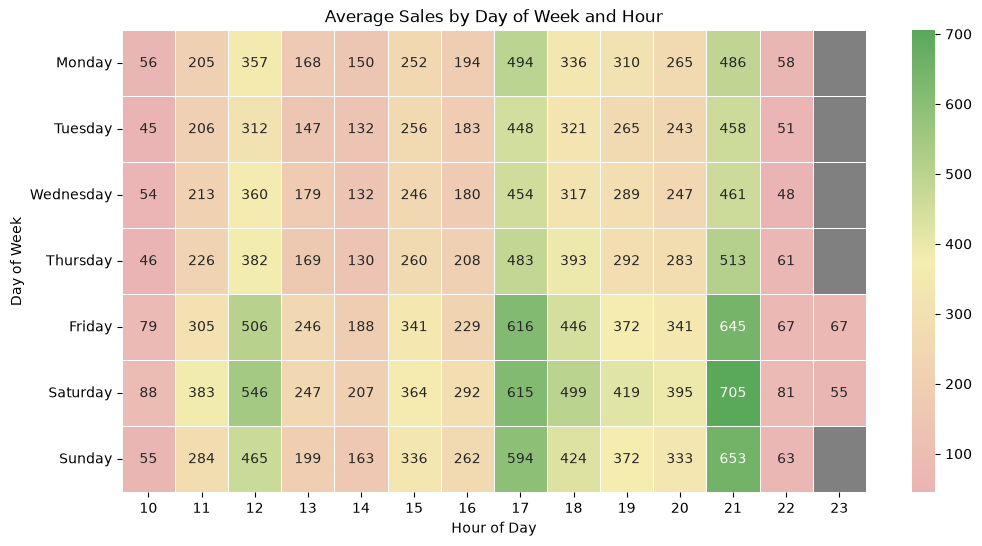

In [15]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
# Ordered categorical so the heatmap rows read Mon->Sun instead of pandas' default alphabetical sort
df['Day_of_Week'] = pd.Categorical(df['Day_of_Week'], categories=day_order, ordered=True)

sales_sum = df.pivot_table(
  index='Day_of_Week',
  columns='Hour',
  values='Item_Price',
  aggfunc='sum'
)

# Number of times each weekday actually occurred, used as the averaging denominator
day_counts = (
  df['Order_Date']
  .dt.normalize()
  .drop_duplicates()
  .dt.day_name()
  .value_counts()
  .reindex(day_order)
)

avg_sales = sales_sum.div(day_counts, axis=0)

soft_cmap = LinearSegmentedColormap.from_list(
  'soft_rdylgn', ['#eab4b4', '#f5edb0', '#5aa85a']
)

plt.figure(figsize=(12, 6))
ax = plt.gca()
ax.set_facecolor('grey')
sns.heatmap(avg_sales, cmap=soft_cmap, annot=True, fmt='.0f', linewidths=0.5, linecolor='white')
plt.title('Average Sales by Day of Week and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.savefig('../output/sales_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Sales Heatmap by Order Type

The heatmap above shows overall busyness by day and hour, but not *why* those hours are busy. Splitting the same heatmap into dine-in (`TABLE`) and to-go (`TO GO`) versions shows whether a busy slot is driven by tables filling up or by pickup/delivery volume, which points to different staffing responses (e.g. an extra server vs. a to-go-only staffer). Both heatmaps share the same color scale so they can be compared directly against each other.

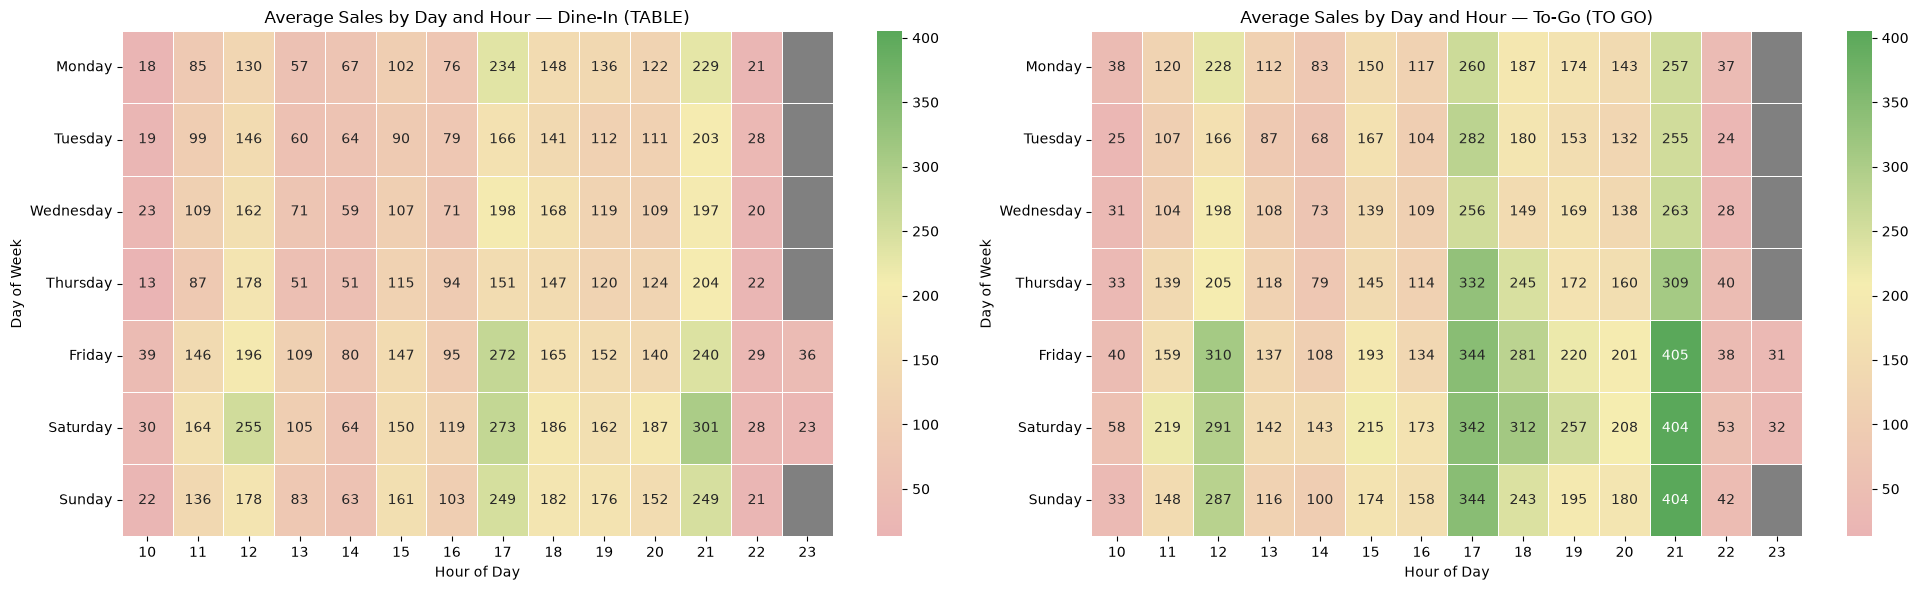

In [16]:
def avg_sales_by_hour_day(order_type, day_counts):
  '''Average sales per day-and-hour slot for a single order type.'''
  subset = df[df['Order_Type'] == order_type]

  sales_sum = subset.pivot_table(
    index='Day_of_Week',
    columns='Hour',
    values='Item_Price',
    aggfunc='sum'
  )

  return sales_sum.div(day_counts, axis=0)

avg_sales_table = avg_sales_by_hour_day('TABLE', day_counts)
avg_sales_togo = avg_sales_by_hour_day('TO GO', day_counts)

# Use the same color scale on both heatmaps so they're directly comparable
vmin = min(avg_sales_table.min().min(), avg_sales_togo.min().min())
vmax = max(avg_sales_table.max().max(), avg_sales_togo.max().max())

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, data, title in zip(
  axes,
  [avg_sales_table, avg_sales_togo],
  ['Dine-In (TABLE)', 'To-Go (TO GO)']
):
  ax.set_facecolor('grey')
  sns.heatmap(
    data, cmap=soft_cmap, annot=True, fmt='.0f',
    linewidths=0.5, linecolor='white',
    vmin=vmin, vmax=vmax, ax=ax
  )
  ax.set_title(f'Average Sales by Day and Hour — {title}')
  ax.set_xlabel('Hour of Day')
  ax.set_ylabel('Day of Week')

plt.tight_layout()
plt.savefig('../output/sales_heatmap_by_order_type.png', dpi=150, bbox_inches='tight')
plt.show()

### Top 15 Items by Units Sold

`TOGO` is excluded from this ranking. It's the \$0.50 to-go bag fee that Washington state mandates restaurants charge, not a food item, so it doesn't belong in a menu popularity ranking. `Side Orders` are also excluded. They're low-priced, high-frequency add-ons (rice, extra soup, etc.) that would dominate a ranking by count without reflecting what's actually driving customers to order.

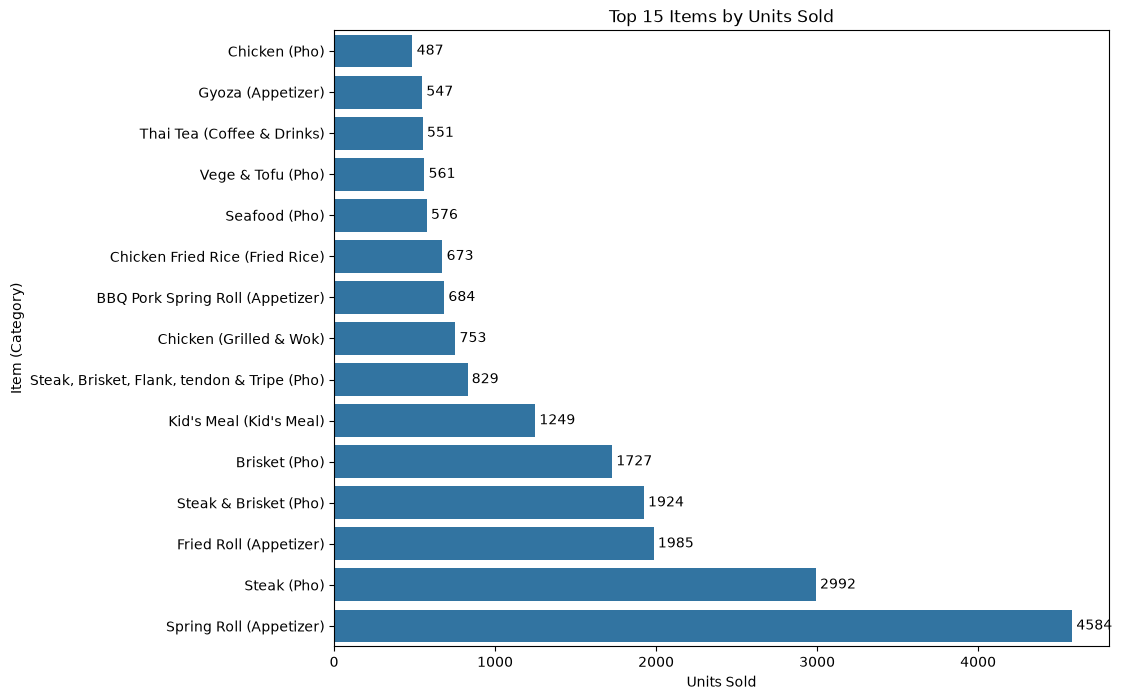

In [17]:
item_counts = (
  df[~df['Category'].isin(['TOGO', 'Side Orders'])]
  .groupby(['Item', 'Category'])
  .size()
  .sort_values(ascending=False)
)

top_items = item_counts.head(15)

labels = [f'{item} ({category})' for item, category in top_items.index]

plt.figure(figsize=(10, 8))
ax = sns.barplot(x=top_items.values, y=labels, orient='h')
ax.bar_label(ax.containers[0], padding=3)
ax.invert_yaxis()
plt.title('Top 15 Items by Units Sold')
plt.xlabel('Units Sold')
plt.ylabel('Item (Category)')
plt.savefig('../output/top15_items_units_sold.png', dpi=150, bbox_inches='tight')
plt.show()

### 15 Lowest Selling Items

Same filtering and grouping as above, sorted in the opposite direction to surface the weakest-performing items on the menu.

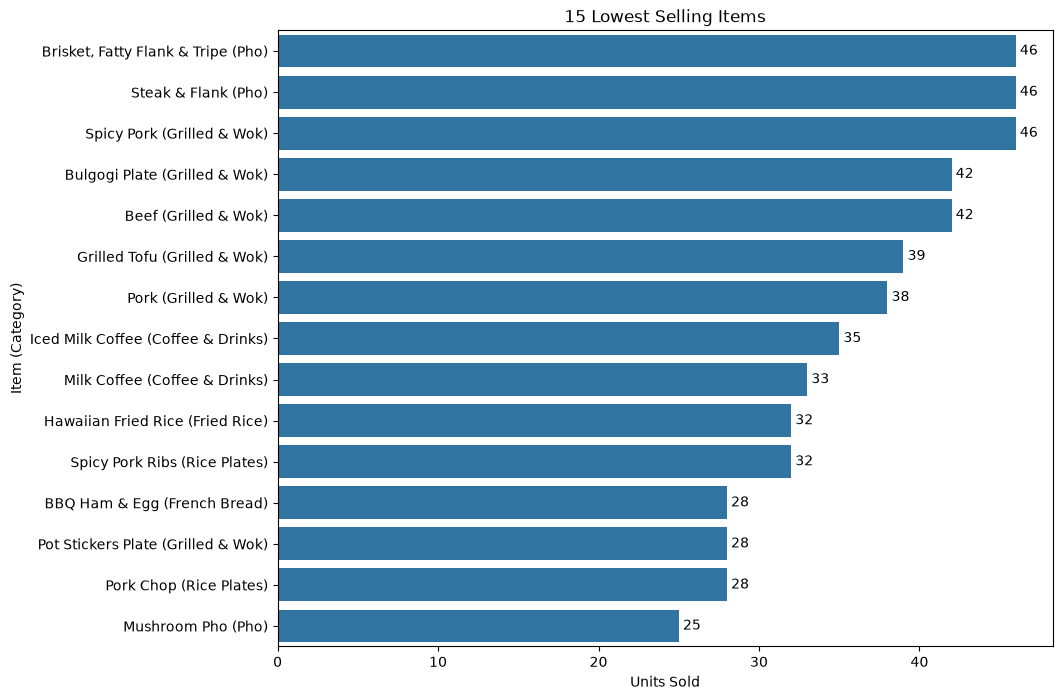

In [18]:
bottom_items = item_counts.sort_values(ascending=True).head(15)

labels = [f'{item} ({category})' for item, category in bottom_items.index]

plt.figure(figsize=(10, 8))
ax = sns.barplot(x=bottom_items.values, y=labels, orient='h')
ax.bar_label(ax.containers[0], padding=3)
ax.invert_yaxis()
plt.title('15 Lowest Selling Items')
plt.xlabel('Units Sold')
plt.ylabel('Item (Category)')
plt.savefig('../output/bottom15_items_units_sold.png', dpi=150, bbox_inches='tight')
plt.show()

### Top 15 Items by Revenue

Ranking by units sold treats a \$0.50 item and an \$18 item as equally important if they sell the same number of times. Ranking by revenue instead shows which items actually drive the business's income. This can (and does) produce a different list than the units-sold ranking above. Same filtering as before: `TOGO` and `Side Orders` excluded, grouped by `Item` and `Category`.

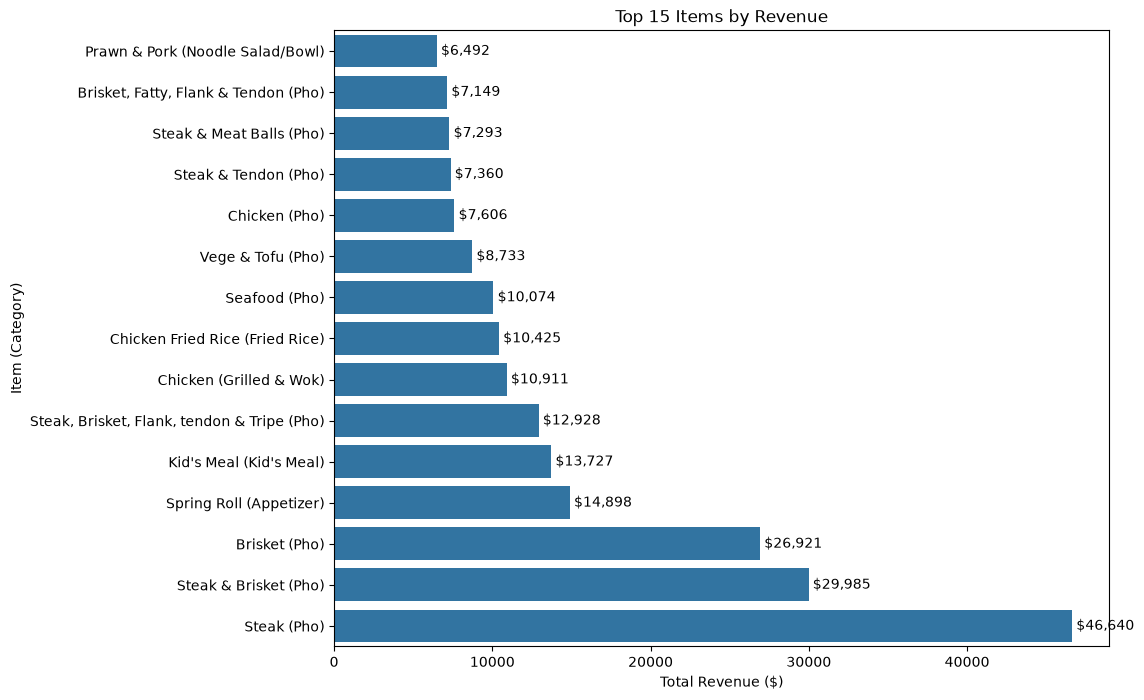

In [19]:
item_revenue = (
  df[~df['Category'].isin(['TOGO', 'Side Orders'])]
  .groupby(['Item', 'Category'])['Item_Price']
  .sum()
  .sort_values(ascending=False)
)

top_revenue = item_revenue.head(15)

labels = [f'{item} ({category})' for item, category in top_revenue.index]

plt.figure(figsize=(10, 8))
ax = sns.barplot(x=top_revenue.values, y=labels, orient='h')
ax.bar_label(ax.containers[0], fmt='${:,.0f}', padding=3)
ax.invert_yaxis()
plt.title('Top 15 Items by Revenue')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Item (Category)')
plt.savefig('../output/top15_items_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

### 15 Lowest Revenue Items

Same filtering and grouping as above, sorted ascending to surface the weakest revenue-generating items on the menu.

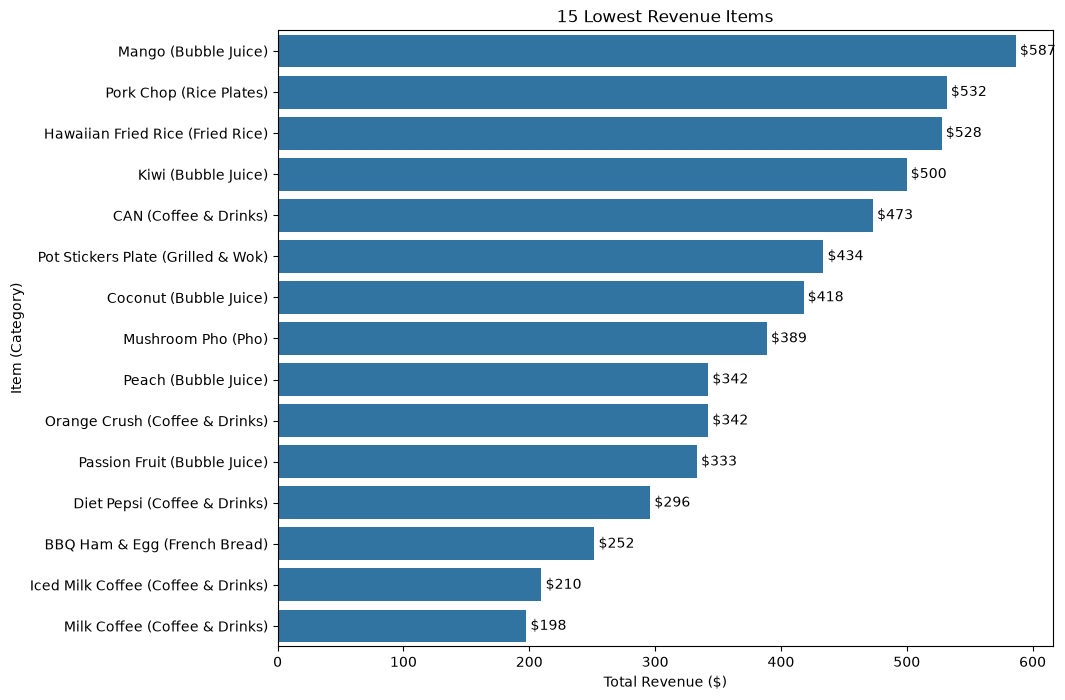

In [20]:
bottom_revenue = item_revenue.sort_values(ascending=True).head(15)

labels = [f'{item} ({category})' for item, category in bottom_revenue.index]

plt.figure(figsize=(10, 8))
ax = sns.barplot(x=bottom_revenue.values, y=labels, orient='h')
ax.bar_label(ax.containers[0], fmt='${:,.0f}', padding=3)
ax.invert_yaxis()
plt.title('15 Lowest Revenue Items')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Item (Category)')
plt.savefig('../output/bottom15_items_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

### Weekly Revenue Trend

This chart checks whether revenue shows any upward or downward trend across the quarter. It's worth noting this is an internal comparison only. There is no prior period (a previous quarter, or the same months last year) to benchmark against, so any pattern found here describes movement within this 13-week window, not growth or decline relative to a baseline.

This is also why dropping `Order_Subtotal` back in Data Cleaning didn't cost anything: it was an order-level total repeated on every line, and summing `Item_Price` (the line-level value) across a week reconstructs the same total without any double counting.

**On the `.iloc[1:-1]` below:** the data runs Jun 3 (a Wednesday) through Sep 2 (also a Wednesday), which doesn't align to calendar week boundaries. The first bucket therefore covers only Wed–Sun (5 days) and the last covers only Mon–Wed (3 days). Both are printed below for transparency, then trimmed. Left in, they would produce a steep drop at each end of the line that reflects missing days rather than any real change in business.

Order_Date
2026-06-07    20861.54
2026-06-14    26619.85
2026-06-21    26062.80
2026-06-28    25840.10
2026-07-05    26197.27
2026-07-12    25705.51
2026-07-19    26080.72
2026-07-26    27256.70
2026-08-02    26250.25
2026-08-09    26911.69
2026-08-16    27692.99
2026-08-23    26935.34
2026-08-30    26792.13
2026-09-06     9364.34
Freq: W-SUN, Name: Item_Price, dtype: float64


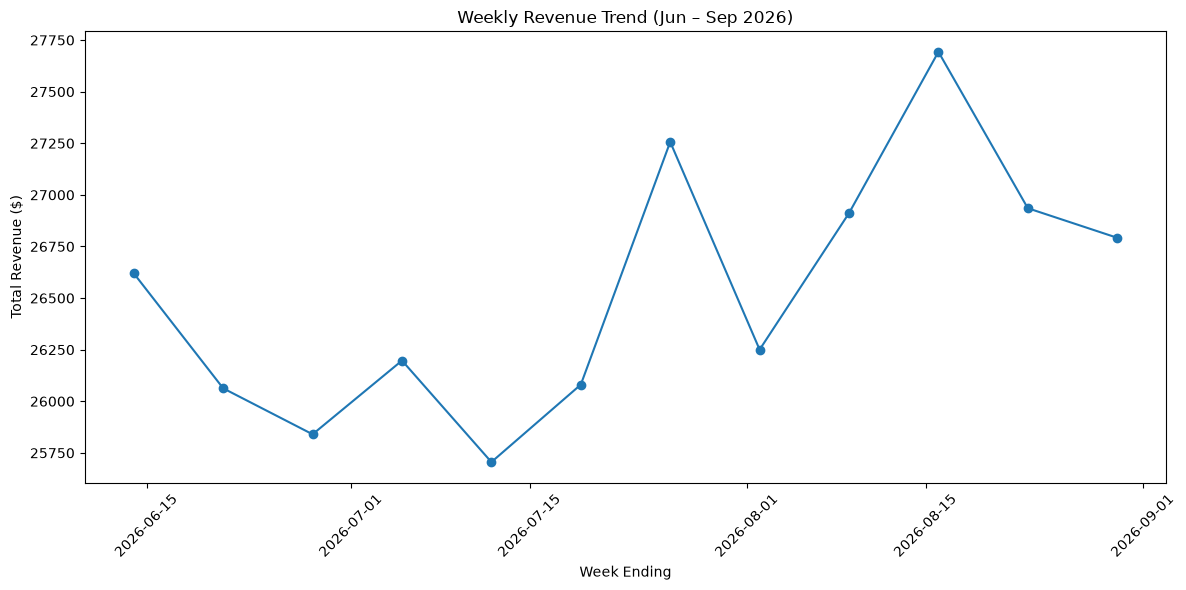

In [21]:
weekly_revenue = df.resample('W', on='Order_Date')['Item_Price'].sum()
print(weekly_revenue)
weekly_revenue = weekly_revenue.iloc[1:-1]

plt.figure(figsize=(12, 6))
plt.plot(weekly_revenue.index, weekly_revenue.values, marker='o')
plt.title('Weekly Revenue Trend (Jun – Sep 2026)')
plt.xlabel('Week Ending')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../output/weekly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# Conclusion

My parents felt like business had been slowing down and wanted a specific number they could see, rather than just a feeling from being there every day. This analysis was meant to check that feeling against the actual data.

### Questions this analysis set out to answer
- When is the restaurant busiest, by day and hour?
- Which menu items are the most popular and most profitable, and are they the same?
- Is revenue trending up, down, or holding steady?

### Key findings
- Demand peaks around 12PM, 5PM, and 9PM. This is expected, coming from the lunch and dinner rushes plus late night people looking for something to order.
- Those peaks are mostly driven by to-go orders rather than dine-in.
- Friday, Saturday, and Sunday are the busiest days. Tuesday is the slowest.
- Steak (Pho) was both a top seller and the top revenue item. Some items are popular but don't make much money. Appetizers like Spring Roll sell a lot but rank lower in revenue.
- Revenue stayed flat across the quarter at roughly \$26,000 per week, so the business is holding steady rather than growing or declining. **This contradicts what my parents assumed going in.** The data doesn't support "business is slowing down." That's worth telling them directly, since it changes the conversation from "how do we stop the decline" to "how do we grow from a stable baseline."

### Business recommendations
- 1PM-4PM is where a lot of the dead time occurs. We should run a targeted special sale/happy hour to drive more traffic to the store.
- Tuesday specifically is the slowest day. A special promotion to get customers in on Tuesdays should help.
- Since the peaks are mostly to-go orders, extra help at 5PM and 9PM should focus on packing to-go orders instead of table service.

# Further Analysis

I wanted to do more advanced data analysis so I decided to do a Moving Average baseline and a Naive forecast on this dataset to predict future revenue and if the suggested promotions had a quantifiable impact. 

In [22]:
df.head()

,Item,Size,Category,Order_Date,Item_Price,Invoice_Number,Order_Type,Table_Number,Payment_Type,Hour,Day_of_Week
Line ID,,,,,,,,,,,
1,Steak & Brisket,Small,Pho,2026-06-03 10:17:00,14.99,185255,TABLE,A2,Credit Card,10,Wednesday
2,NO MEAT PHO LARGE,NaN,Pho,2026-06-03 10:17:00,12.99,185255,TABLE,A2,Credit Card,10,Wednesday
3,Kid's Meal,NaN,Kid's Meal,2026-06-03 10:19:00,10.99,185256,TO GO,NaN,Credit Card,10,Wednesday
4,Brisket,Small,Pho,2026-06-03 10:19:00,14.99,185256,TO GO,NaN,Credit Card,10,Wednesday
5,Chicken,NaN,Grilled & Wok,2026-06-03 10:19:00,14.49,185256,TO GO,NaN,Credit Card,10,Wednesday


We can use the weekly_revenue series we made earlier and tweak it so its a DataFrame instead of a series.  
`weekly_revenue = df.resample('W', on='Order_Date')['Item_Price'].sum()`

In [23]:
#daily_sales = df.groupby('Order_Date')['Item_Price'].sum().reset_index()
weekly_sales_df = weekly_revenue.to_frame(name='Weekly Revenue')
weekly_sales_df.head()

,Weekly Revenue
Order_Date,
2026-06-14,26619.85
2026-06-21,26062.80
2026-06-28,25840.10
2026-07-05,26197.27
2026-07-12,25705.51


In [24]:
weekly_sales_df['Naive_Forecast'] = weekly_sales_df['Weekly Revenue'].shift(1)
weekly_sales_df['3_Week_MA'] = weekly_sales_df['Weekly Revenue'].shift(1).rolling(window=3).mean()

In [25]:
future_date = weekly_sales_df.index[-1] + pd.Timedelta(weeks=1)
weekly_sales_df.loc[future_date] = [None, None, None]

weekly_sales_df.loc[future_date, 'Naive_Forecast'] = weekly_sales_df['Weekly Revenue'].iloc[-2]
weekly_sales_df.loc[future_date, '3_Week_MA'] = weekly_sales_df['Weekly Revenue'].iloc[-4:-1].mean()

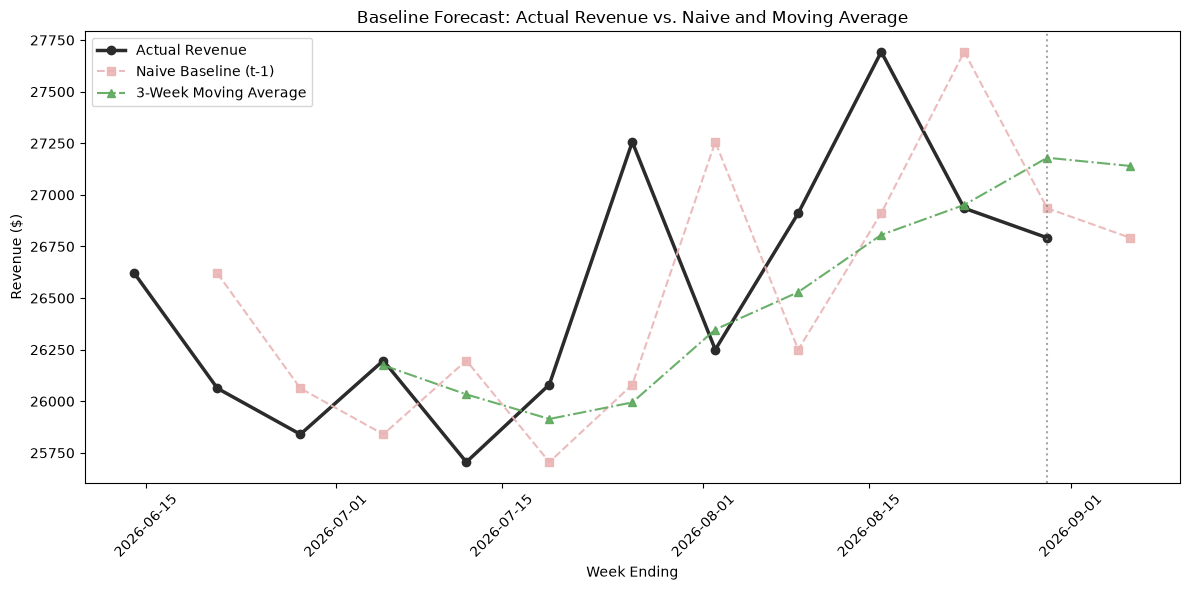

In [26]:
plt.figure(figsize=(12, 6))
plt.plot(weekly_sales_df.index[:-1], weekly_sales_df['Weekly Revenue'].dropna(), label='Actual Revenue', color='#2b2b2b', marker='o', linewidth=2.5)
plt.plot(weekly_sales_df.index, weekly_sales_df['Naive_Forecast'], label='Naive Baseline (t-1)', color='#eab4b4', linestyle='--', marker='s', alpha=0.9)
plt.plot(weekly_sales_df.index, weekly_sales_df['3_Week_MA'], label='3-Week Moving Average', color='#5aa85a', linestyle='-.', marker='^', alpha=0.9)
plt.title('Baseline Forecast: Actual Revenue vs. Naive and Moving Average')
plt.xlabel('Week Ending')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.legend()
plt.axvline(x=weekly_sales_df.index[-2], color='gray', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig('../output/weekly_revenue_baseline.png', dpi=150, bbox_inches='tight')
plt.show()


### Checking the Forecast Against Real Data

I wanted to check the forecast against real data to see if my suggestions actually made a quantifiable difference. I grabbed another week of raw data from their POS system (Sep 3–9), which also happened to include a new Combo item they started testing based on one of my suggestions. My original data cuts off Sep 2 and this new file picks up right at Sep 3, so there's no gap or overlap between the two.

That matters because the last row in `weekly_sales_df`, the one `future_date` predicted, is the week ending Sep 6, and that week was sitting incomplete in my original data (I only had Sep 1–2 of it, which is why it got trimmed out of the trend chart earlier). Combined with the new file, that week is now a full 7 days, so I can drop in the real number and see how far off the baselines actually were.

In [27]:
new_data = pd.read_csv('../data/restaurant_sales_sept03_09.csv')
new_data = new_data.rename(columns={'Order Date': 'Order_Date', 'Item Price': 'Item_Price'})
new_data['Order_Date'] = pd.to_datetime(new_data['Order_Date'])

# Combine just for this check, df itself stays as the original 13-week dataset used above
combined_revenue = pd.concat([
  df[['Order_Date', 'Item_Price']],
  new_data[['Order_Date', 'Item_Price']]
]).resample('W', on='Order_Date')['Item_Price'].sum()

combined_revenue.tail()

Order_Date
2026-08-16    27692.99
2026-08-23    26935.34
2026-08-30    26792.13
2026-09-06    26355.79
2026-09-13    10312.51
Freq: W-SUN, Name: Item_Price, dtype: float64

Sep 7–9 also shows up in `combined_revenue`, but that's only 3 days of the *next* week, so it's the same partial-week problem as before. I'm leaving that one out until I actually have the rest of it. Only the Sep 6 week is complete enough to use.

In [28]:
# Fill in the real number for the week I forecasted, instead of leaving it blank
actual_next_week = combined_revenue.loc[future_date]
weekly_sales_df.loc[future_date, 'Weekly Revenue'] = actual_next_week

weekly_sales_df.tail()

,Weekly Revenue,Naive_Forecast,3_Week_MA
Order_Date,,,
2026-08-09,26911.69,26250.25,26529.223333
2026-08-16,27692.99,26911.69,26806.213333
2026-08-23,26935.34,27692.99,26951.643333
2026-08-30,26792.13,26935.34,27180.006667
2026-09-06,26355.79,26792.13,27140.153333


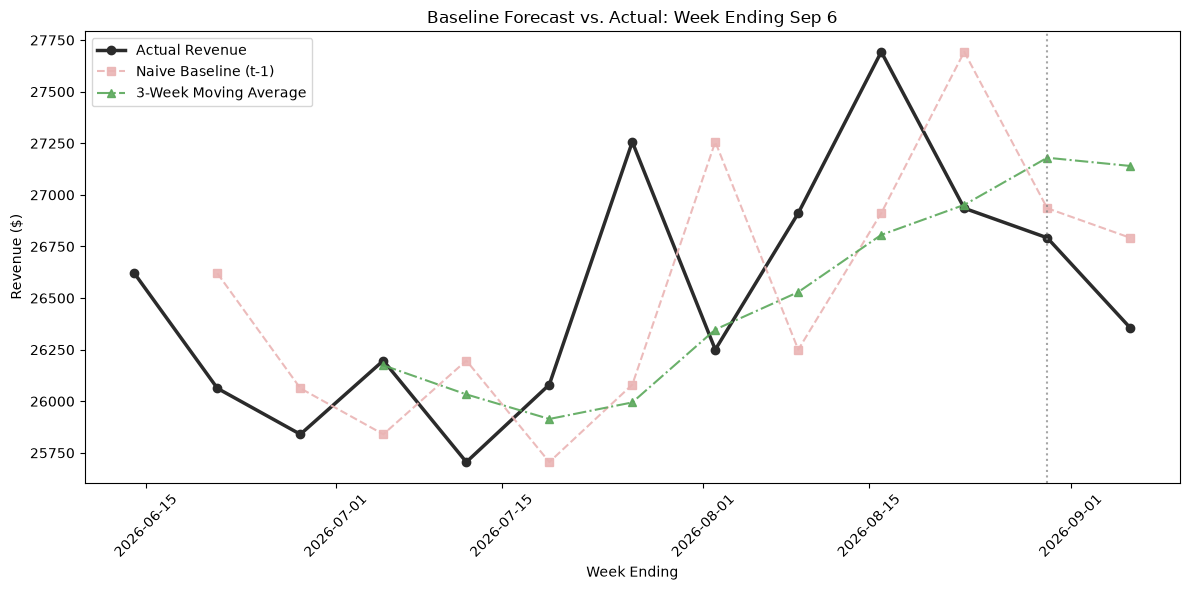

In [29]:
# weekly_sales_df.index[:-1] no longer works to isolate the actuals here since the last row
# isn't blank anymore, so drop NaNs directly off Weekly Revenue instead
actuals = weekly_sales_df['Weekly Revenue'].dropna()

plt.figure(figsize=(12, 6))
plt.plot(actuals.index, actuals.values, label='Actual Revenue', color='#2b2b2b', marker='o', linewidth=2.5)
plt.plot(weekly_sales_df.index, weekly_sales_df['Naive_Forecast'], label='Naive Baseline (t-1)', color='#eab4b4', linestyle='--', marker='s', alpha=0.9)
plt.plot(weekly_sales_df.index, weekly_sales_df['3_Week_MA'], label='3-Week Moving Average', color='#5aa85a', linestyle='-.', marker='^', alpha=0.9)
plt.title('Baseline Forecast vs. Actual: Week Ending Sep 6')
plt.xlabel('Week Ending')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.legend()
plt.axvline(x=weekly_sales_df.index[-2], color='gray', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig('../output/weekly_revenue_baseline_actual.png', dpi=150, bbox_inches='tight')
plt.show()

### Result

Actual revenue for the week ending Sep 6 came in at **$26,356**. Naive was about **1.7% off**, and the 3-Week MA was about **3.0% off**. Both landed a bit high, meaning actual revenue came in below what either baseline expected.

That's only one week of data with the new Combo item in it, so it's too early to say the changes made a real difference either way. If anything, this week doesn't show a lift yet. I want to keep comparing actual revenue against these baselines over the next several weeks to see if a clearer pattern shows up.